In [ ]:
#!pip install nlp

In [ ]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer




from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import classification_report

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
lemmatizer= WordNetLemmatizer()
nltk.download('wordnet')
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

sns.set(font_scale=1.3)
nltk.download('omw-1.4')

import random

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
#dataset: https://www.kaggle.com/datasets/parulpandey/emotion-dataset?resource=download
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving training.csv to training (1).csv
Saving validation.csv to validation (1).csv


In [ ]:
#sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5).
df_train = pd.read_csv('training.csv', names=['Text', 'Emotion'], sep=',')
df_val = pd.read_csv('validation.csv', names=['Text', 'Emotion'], sep=',')
df_test = pd.read_csv('test.csv', names=['Text', 'Emotion'], sep=',')

df_train = df_train.drop(0)
df_val = df_val.drop(0)
df_test = df_test.drop(0)

In [ ]:
df_train.head()

,Text,Emotion
1,i didnt feel humiliated,0
2,i can go from feeling so hopeless to so damned...,0
3,im grabbing a minute to post i feel greedy wrong,3
4,i am ever feeling nostalgic about the fireplac...,2
5,i am feeling grouchy,3


In [ ]:
disp=df_train.copy()
def number_to_word(number):
    words = {
        '0': 'sadness',
        '1': 'joy',
        '2': 'love',
        '3': 'anger',
        '4': 'fear',
        '5':'surprise'
    }
    return words.get(number, number)

def replace_numbers_with_words(column):
    return [number_to_word(num) for num in column]

disp['Emotion'] = replace_numbers_with_words(disp['Emotion'])

disp.head()

,Text,Emotion
1,i didnt feel humiliated,sadness
2,i can go from feeling so hopeless to so damned...,sadness
3,im grabbing a minute to post i feel greedy wrong,anger
4,i am ever feeling nostalgic about the fireplac...,love
5,i am feeling grouchy,anger


Basic EDA

In [ ]:

list_elements_limit=10
row_limit=5

dtypes_df = pd.DataFrame(df_train.dtypes).reset_index().rename(columns={0:'dtype', 'index':'column_name'})
cat_df = dtypes_df[dtypes_df['dtype']=='object']
print('There are {} categorical columns'.format(len(cat_df)))

if list_elements_limit >= len(cat_df):
    print("Categorical columns : ", list(cat_df['column_name']))
else:
    print("Categorical columns : ", list(cat_df['column_name'])[:list_elements_limit])


display(dtypes_df.head(row_limit))


There are 2 categorical columns
Categorical columns :  ['Text', 'Emotion']


,column_name,dtype
0,Text,object
1,Emotion,object


In [ ]:
disp.Emotion.value_counts()

joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: Emotion, dtype: int64

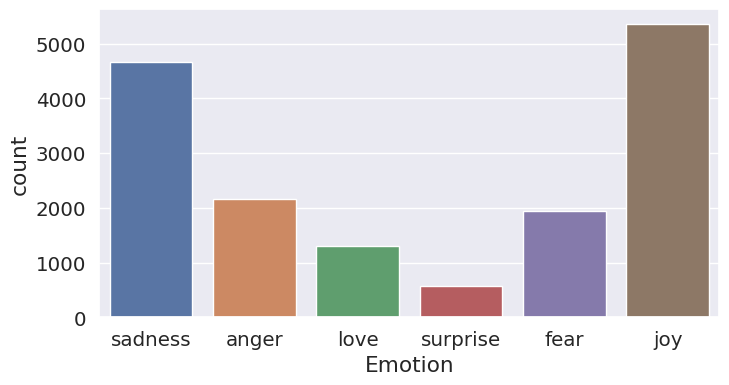

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=disp);

Pre-processing

In [ ]:
def lemmatization(text):
    lemmatizer= WordNetLemmatizer()

    text = text.split()

    text=[lemmatizer.lemmatize(y) for y in text]

    return " " .join(text)

def remove_stop_words(text):

    Text=[i for i in str(text).split() if i not in stop_words]
    return " ".join(Text)

def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

def lower_case(text):

    text = text.split()

    text=[y.lower() for y in text]

    return " " .join(text)

def Removing_punctuations(text):
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    text = text.replace('؛',"", )

    #remove extra whitespace
    text = re.sub('\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)


def normalize_text(df):
    df.Text=df.Text.apply(lambda text : lower_case(text))
    df.Text=df.Text.apply(lambda text : remove_stop_words(text))
    df.Text=df.Text.apply(lambda text : Removing_numbers(text))
    df.Text=df.Text.apply(lambda text : Removing_punctuations(text))
    df.Text=df.Text.apply(lambda text : Removing_urls(text))
    df.Text=df.Text.apply(lambda text : lemmatization(text))
    return df

def normalized_sentence(sentence):
    sentence= lower_case(sentence)
    sentence= remove_stop_words(sentence)
    sentence= Removing_numbers(sentence)
    sentence= Removing_punctuations(sentence)
    sentence= Removing_urls(sentence)
    sentence= lemmatization(sentence)
    return sentence



In [ ]:
#example of pre-processed sentence
normalized_sentence("Hello, this is a test sentence to showcase pre-processing @hello, #hello")

'hello test sentence showcase pre processing hello hello'

In [ ]:
df_train= normalize_text(df_train)
df_test= normalize_text(df_test)
df_val= normalize_text(df_val)

In [ ]:
df_train.head()

,Text,Emotion
1,didnt feel humiliated,0
2,go feeling hopeless damned hopeful around some...,0
3,im grabbing minute post feel greedy wrong,3
4,ever feeling nostalgic fireplace know still pr...,2
5,feeling grouchy,3


In [ ]:
#save preprocessed data to csv
# df_train.to_csv("train_pp.csv", index=False)
# df_test.to_csv("test_pp.csv", index=False)
# df_val.to_csv("val_pp.csv", index=False)

In [ ]:
X_train = df_train['Text'].values
y_train = df_train['Emotion'].values

X_test = df_test['Text'].values
y_test = df_test['Emotion'].values

X_val = df_val['Text'].values
y_val = df_val['Emotion'].values

Tokenizing and padding

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

max_length = 70
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length)
X_val_padded = pad_sequences(X_val_sequences, maxlen=max_length)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test=np.array(y_test)

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded =label_encoder.transform(y_test)

Deep Learning models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def train_model(model, data, targets):
    text_clf = Pipeline([
    ('vect', CountVectorizer(analyzer='char_wb',ngram_range=(4,7),stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('clf', model),
    ])
    text_clf.fit(data, targets)
    return text_clf
def get_accuracy(trained_model,X, y):
    predicted = trained_model.predict(X)
    accuracy = np.mean(predicted == y)
    return accuracy
def get_report(trained_model,X, y):
    plt.figure(figsize=(10,10))
    predicted = trained_model.predict(X)
    cr = classification_report(y,predicted,target_names=label_encoder.classes_)
    cm=confusion_matrix(y,predicted)
    df_cm=pd.DataFrame(cm,index=label_encoder.classes_)
    classes= ['sadness', 'joy', 'love','anger', 'fear', 'suprrise']
    sns.heatmap(df_cm, annot=True,fmt='d',xticklabels=classes, yticklabels=classes)
    plt.show()
    print(cr)

Logistic Regression

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:550: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test dataset accuracy with LogisticRegression: 0.87


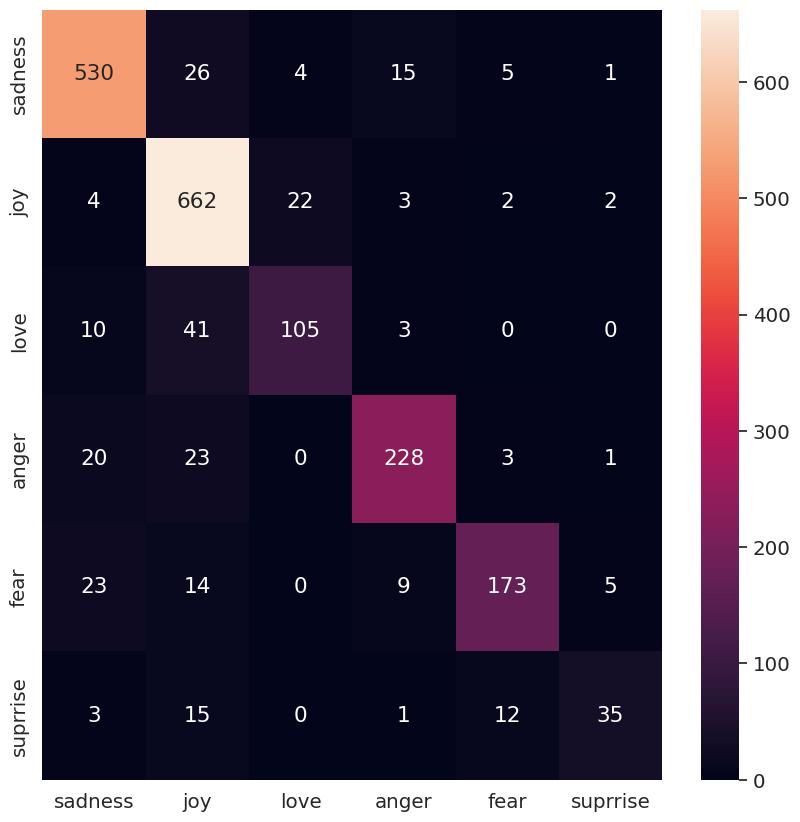

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       581
           1       0.85      0.95      0.90       695
           2       0.80      0.66      0.72       159
           3       0.88      0.83      0.85       275
           4       0.89      0.77      0.83       224
           5       0.80      0.53      0.64        66

    accuracy                           0.87      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.87      0.87      0.86      2000



In [ ]:
LR = train_model(LogisticRegression(), X_train, y_train)
accuracyLR = get_accuracy(LR,X_test, y_test)
print(f"Test dataset accuracy with LogisticRegression: {accuracyLR:.2f}")
get_report(LR,X_test, y_test)

SVC

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:550: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


Test dataset accuracy with LinearSVC: 0.87


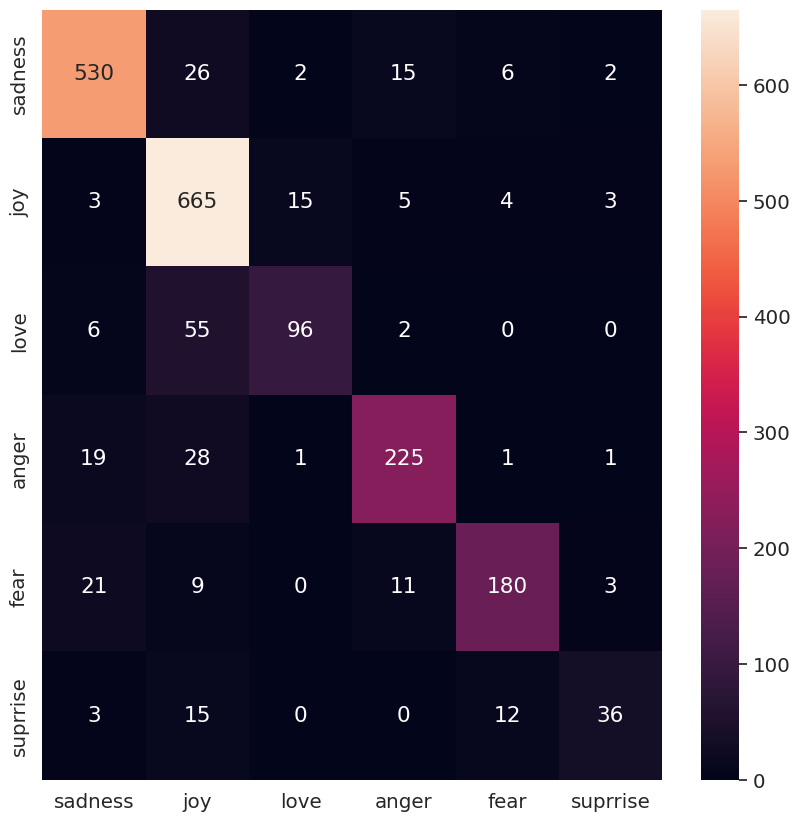

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       581
           1       0.83      0.96      0.89       695
           2       0.84      0.60      0.70       159
           3       0.87      0.82      0.84       275
           4       0.89      0.80      0.84       224
           5       0.80      0.55      0.65        66

    accuracy                           0.87      2000
   macro avg       0.86      0.77      0.81      2000
weighted avg       0.87      0.87      0.86      2000



In [ ]:
SVC = train_model(SVC(), X_train, y_train)
accuracySVC = get_accuracy(SVC,X_test, y_test)
print(f"Test dataset accuracy with LinearSVC: {accuracySVC:.2f}")
get_report(SVC,X_test, y_test)


MLP Classifier

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:550: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


Iteration 1, loss = 1.27240102
Iteration 2, loss = 0.48175654
Iteration 3, loss = 0.22760627


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(


Test dataset accuracy with MLPClassifier: 0.86


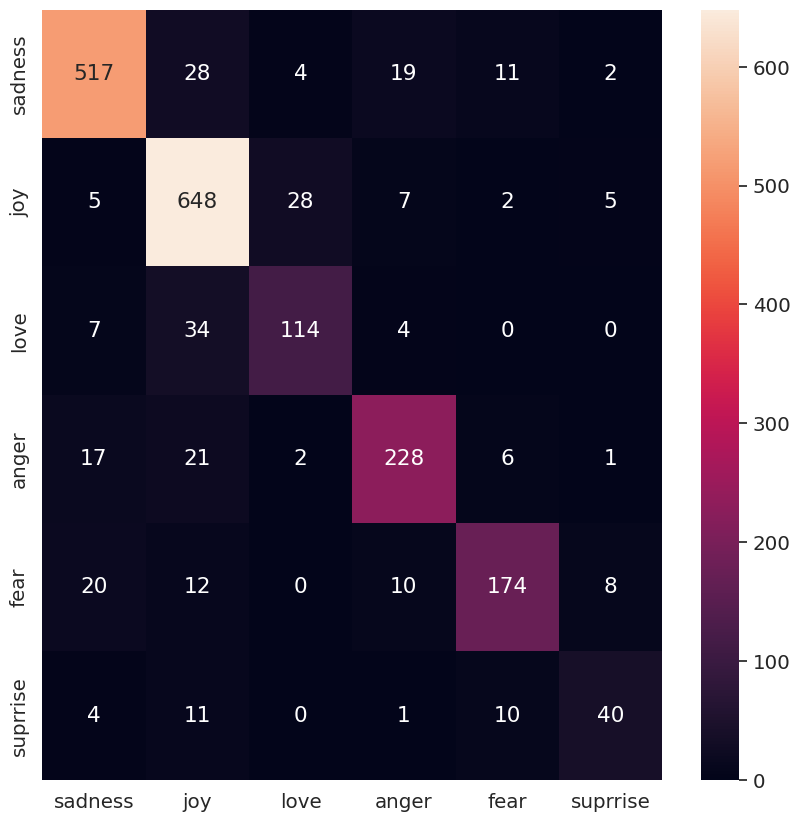

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       581
           1       0.86      0.93      0.89       695
           2       0.77      0.72      0.74       159
           3       0.85      0.83      0.84       275
           4       0.86      0.78      0.81       224
           5       0.71      0.61      0.66        66

    accuracy                           0.86      2000
   macro avg       0.83      0.79      0.81      2000
weighted avg       0.86      0.86      0.86      2000



In [ ]:
MLP = train_model(MLPClassifier(verbose=1,max_iter=3,validation_fraction=0.1), X_train, y_train)
accuracyMLP = get_accuracy(MLP,X_test, y_test)
print(f"Test dataset accuracy with MLPClassifier: {accuracyMLP:.2f}")
get_report(MLP,X_test, y_test)
#get_report(trained_clf_MLPClassifier,X_train, y_train)

Decision Tree

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:550: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


Test dataset accuracy with MLPClassifier: 0.80


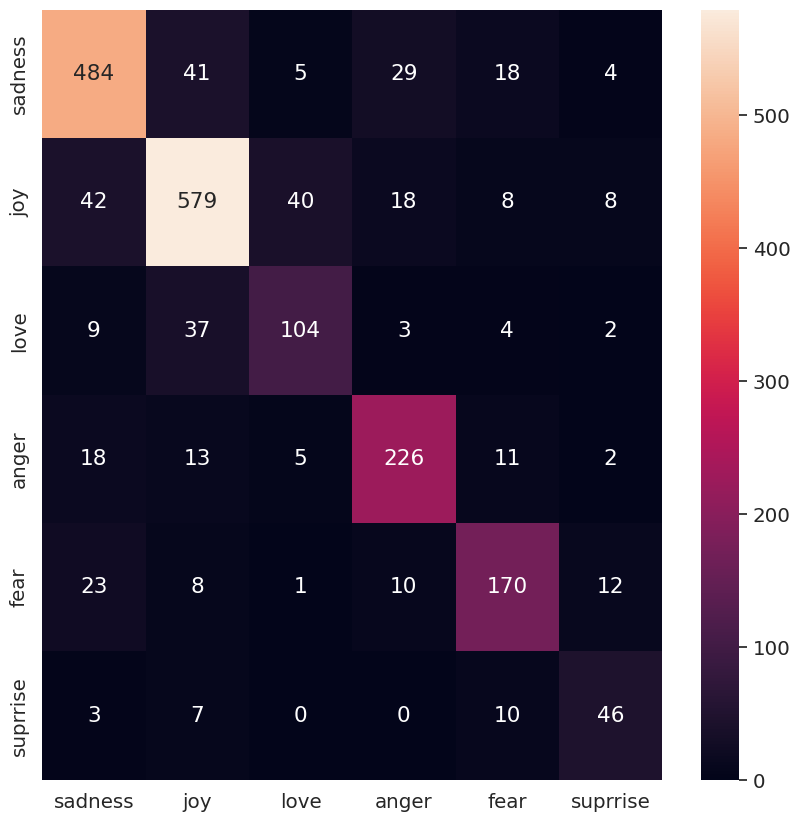

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       581
           1       0.85      0.83      0.84       695
           2       0.67      0.65      0.66       159
           3       0.79      0.82      0.81       275
           4       0.77      0.76      0.76       224
           5       0.62      0.70      0.66        66

    accuracy                           0.80      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.81      0.80      0.80      2000



In [ ]:
DT = train_model(DecisionTreeClassifier(), X_train, y_train)
accuracyDT = get_accuracy(DT,X_test, y_test)
print(f"Test dataset accuracy with MLPClassifier: {accuracyDT:.2f}")
get_report(DT,X_test, y_test)
#get_report(trained_clf_DT,X_train, y_train)

Random Forest

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:550: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


Test dataset accuracy with MLPClassifier: 0.88


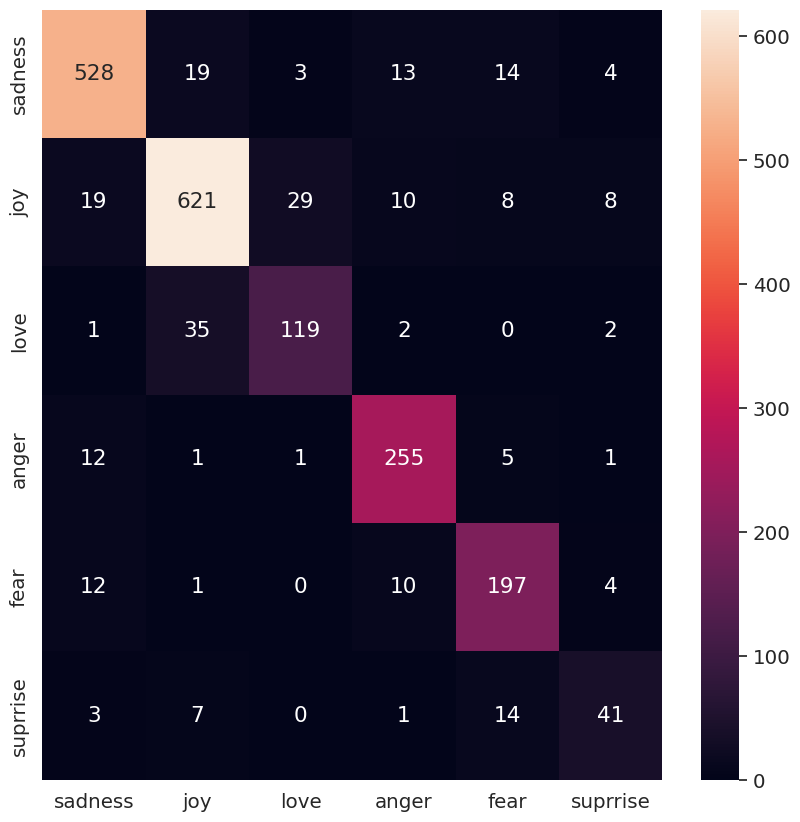

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       581
           1       0.91      0.89      0.90       695
           2       0.78      0.75      0.77       159
           3       0.88      0.93      0.90       275
           4       0.83      0.88      0.85       224
           5       0.68      0.62      0.65        66

    accuracy                           0.88      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.88      0.88      0.88      2000



In [ ]:
RF = train_model(RandomForestClassifier(n_estimators=200), X_train, y_train)
accuracyRF = get_accuracy(RF,X_test, y_test)
print(f"Test dataset accuracy with MLPClassifier: {accuracyRF:.2f}")
get_report(RF,X_test, y_test)
#get_report(trained_clf_RF,X_train, y_train)

Summary

In [ ]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Machine', 'MLP Classifier','Decision Tree','Random Forest'],
    'Accuracy': [accuracyLR.round(2), accuracySVC.round(2), accuracyMLP.round(2), accuracyDT.round(2), accuracyRF]})

models.sort_values(by='Accuracy', ascending=False).reset_index().drop(['index'], axis=1)

,Model,Accuracy
0,Random Forest,0.8805
1,Logistic Regression,0.8700
2,Support Vector Machine,0.8700
3,MLP Classifier,0.8600
4,Decision Tree,0.8000


RNN

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(200, return_sequences=True)),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(200)),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(6, activation='softmax')
])

#lstm 200 dropout 0.2 acc 0.9200

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 70, 16)            160000    
                                                                 
 bidirectional (Bidirectiona  (None, 70, 400)          347200    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 70, 400)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 400)              961600    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 400)               0         
                                                                 
 dense (Dense)               (None, 6)                 2

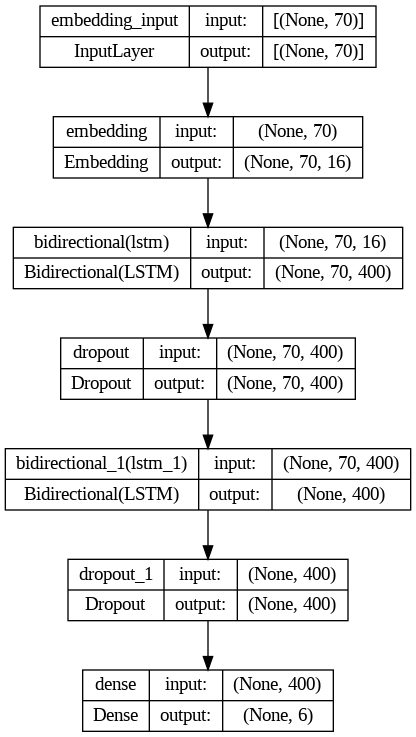

In [ ]:
from keras.utils.vis_utils import plot_model
plot_model(model, show_shapes=True)

In [ ]:
h = model.fit(
    X_train_padded, y_train_encoded,
    validation_data=(X_val_padded, y_val_encoded),
    epochs=10,
)


Epoch 1/10
500/500 [==============================] - 489s 962ms/step - loss: 1.1142 - accuracy: 0.5631 - val_loss: 0.6385 - val_accuracy: 0.7480
Epoch 2/10
500/500 [==============================] - 462s 925ms/step - loss: 0.4085 - accuracy: 0.8576 - val_loss: 0.3631 - val_accuracy: 0.8815
Epoch 3/10
500/500 [==============================] - 439s 878ms/step - loss: 0.2260 - accuracy: 0.9234 - val_loss: 0.2910 - val_accuracy: 0.9020
Epoch 4/10
500/500 [==============================] - 439s 877ms/step - loss: 0.1293 - accuracy: 0.9569 - val_loss: 0.2544 - val_accuracy: 0.9095
Epoch 5/10
500/500 [==============================] - 435s 870ms/step - loss: 0.0990 - accuracy: 0.9636 - val_loss: 0.2934 - val_accuracy: 0.9110
Epoch 6/10
500/500 [==============================] - 444s 888ms/step - loss: 0.0895 - accuracy: 0.9688 - val_loss: 0.2945 - val_accuracy: 0.9080
Epoch 7/10
500/500 [==============================] - 446s 893ms/step - loss: 0.0638 - accuracy: 0.9777 - val_loss: 0.3041 -

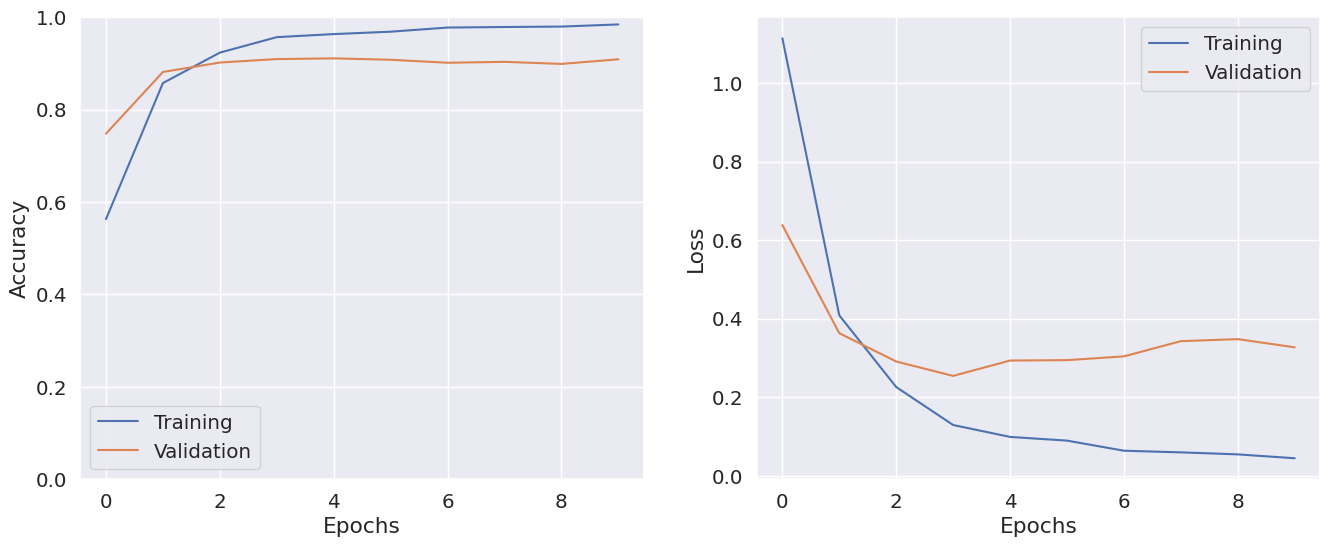

In [ ]:
def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

show_history(h)

In [ ]:
eval = model.evaluate(X_test_padded, y_test_encoded)

63/63 [==============================] - 15s 241ms/step - loss: 0.3041 - accuracy: 0.9105


In [ ]:
predict=model.predict(X_test_padded)
preds=np.argmax(predict,axis=1)

preds.shape, y_test_encoded.shape

63/63 [==============================] - 15s 244ms/step


((2000,), (2000,))

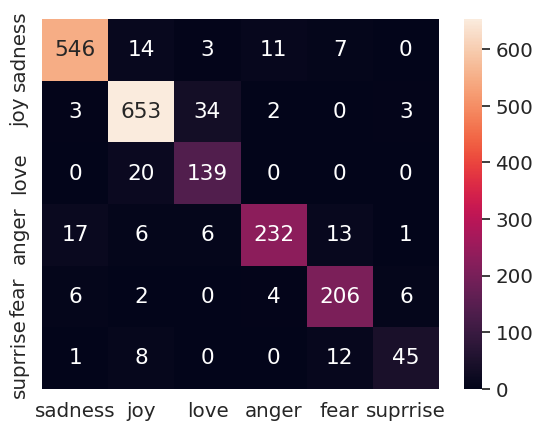

In [ ]:
cm = confusion_matrix(y_test_encoded, preds)

classes= ['sadness', 'joy', 'love','anger', 'fear', 'suprrise']
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.show()

In [ ]:
report = classification_report(y_test_encoded, preds, target_names=classes)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

     sadness       0.95      0.94      0.95       581
         joy       0.93      0.94      0.93       695
        love       0.76      0.87      0.82       159
       anger       0.93      0.84      0.89       275
        fear       0.87      0.92      0.89       224
    suprrise       0.82      0.68      0.74        66

    accuracy                           0.91      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.91      0.91      0.91      2000

